Иванов Артём ИСУ: 501885 J3110

# Лабораторная работа: PCA

Ниже я оставил основной код без Expert level и добавил короткие пояснения перед функциями.  
Идея такая: сначала реализуем свою матрицу и базовые численные методы, потом через них собираем PCA.


## Импорты

Здесь подключаю только то, что нужно дальше в коде: типы, `math` для корней и нормировки, `random` оставлен как стандартный модуль. Основная линейная алгебра дальше реализуется вручную.


In [1]:
from typing import List, Tuple
import math
import random


## `Matrix`

Это мой базовый класс матрицы, чтобы дальше не пользоваться готовой линейной алгеброй.  
В нём хранятся данные, размеры `rows` и `cols`, а также сделаны операции: копирование, перевод в список, нулевая и единичная матрицы, транспонирование, сложение, вычитание, умножение на число и матричное умножение через `@`.

По сути, этот класс нужен как фундамент для Гаусса, ковариационной матрицы и PCA.


In [2]:
class Matrix:
    def __init__(self, data: list[list[float]]):
        if not data:
            raise ValueError("Matrix cannot be empty")

        if not data[0]:
            raise ValueError("Matrix rows cannot be empty")

        cols = len(data[0])

        for row in data:
            if len(row) != cols:
                raise ValueError("All rows must have the same length")

        self.data = [[float(x) for x in row] for row in data]
        self.rows = len(data)
        self.cols = cols

    def __getitem__(self, index):
        if isinstance(index, tuple):
            i, j = index
            return self.data[i][j]

        return self.data[index]

    def __setitem__(self, index: int, value: list[float]) -> None:
        if len(value) != self.cols:
            raise ValueError("Invalid row size")
        self.data[index] = [float(x) for x in value]

    def __repr__(self) -> str:
        return f"Matrix({self.data})"

    def copy(self) -> "Matrix":
        return Matrix([row[:] for row in self.data])

    def to_list(self) -> list[list[float]]:
        return [row[:] for row in self.data]

    @staticmethod
    def zeros(rows: int, cols: int) -> "Matrix":
        return Matrix([[0.0 for _ in range(cols)] for _ in range(rows)])

    @staticmethod
    def identity(n: int) -> "Matrix":
        data = [[0.0 for _ in range(n)] for _ in range(n)]

        for i in range(n):
            data[i][i] = 1.0

        return Matrix(data)

    def T(self) -> "Matrix":
        result = []

        for j in range(self.cols):
            row = []
            for i in range(self.rows):
                row.append(self.data[i][j])
            result.append(row)

        return Matrix(result)

    def __add__(self, other: "Matrix") -> "Matrix":
        if self.rows != other.rows or self.cols != other.cols:
            raise ValueError("Matrix sizes must match")

        result = []

        for i in range(self.rows):
            row = []
            for j in range(self.cols):
                row.append(self[i][j] + other[i][j])
            result.append(row)

        return Matrix(result)

    def __sub__(self, other: "Matrix") -> "Matrix":
        if self.rows != other.rows or self.cols != other.cols:
            raise ValueError("Matrix sizes must match")

        result = []

        for i in range(self.rows):
            row = []
            for j in range(self.cols):
                row.append(self[i][j] - other[i][j])
            result.append(row)

        return Matrix(result)

    def __mul__(self, number: float) -> "Matrix":
        result = []

        for i in range(self.rows):
            row = []
            for j in range(self.cols):
                row.append(self[i][j] * number)
            result.append(row)

        return Matrix(result)

    def __rmul__(self, number: float) -> "Matrix":
        return self * number

    def __matmul__(self, other: "Matrix") -> "Matrix":
        if self.cols != other.rows:
            raise ValueError("Invalid matrix sizes for multiplication")

        result = []

        for i in range(self.rows):
            row = []

            for j in range(other.cols):
                s = 0.0

                for k in range(self.cols):
                    s += self[i][k] * other[k][j]

                row.append(s)

            result.append(row)

        return Matrix(result)

## `merge_matrix(A, b)`

Эта функция делает расширенную матрицу системы: к матрице коэффициентов `A` справа добавляется столбец `b`.  
Она нужна в методе Гаусса, потому что удобнее приводить к ступенчатому виду сразу систему `A|b`, а не отдельно матрицу и правую часть.


In [3]:
def merge_matrix(A: 'Matrix', b: 'Matrix') -> 'Matrix':
  if b.cols != 1:
    raise ValueError("Invalid matrix size")

  if A.rows != b.rows:
    raise ValueError("Invalid matrix size")

  aug = []

  for i in range(A.rows):
    row = A[i][:]
    row.append(b[i][0])
    aug.append(row)

  return Matrix(aug)


## `gauss_solver(A, b)`

Здесь реализован метод Гаусса для решения СЛАУ.  
Я выбираю ведущий элемент, переставляю строки, нормирую строку и зануляю остальные элементы в этом столбце. В итоге получается почти приведённый ступенчатый вид.

Функция умеет обрабатывать три случая: единственное решение, бесконечно много решений и несовместную систему. Это важно для PCA, потому что собственные векторы находятся из системы `(C - λI)v = 0`, а там как раз обычно есть свободные переменные.


In [4]:
def gauss_solver(A: 'Matrix', b: 'Matrix') -> List['Matrix']:
  """
  Вход:
  A: матрица коэффициентов (n×n)
  b: вектор правых частей (n×1)
  Выход:
  list[Matrix]: если решение единственное — [x]; если решений бесконечно много —
  для неоднородной системы [x0, v1, ..., vk], где x0 — частное решение,
  vi — базисные векторы ядра; для однородной системы — только базис ядра.
  Raises:
  ValueError: если система несовместна
  """

  if A.rows != A.cols:
    raise ValueError("A must be square")

  if b.cols != 1:
    raise ValueError("b must be a column vector")

  if A.rows != b.rows:
    raise ValueError("A and b must have the same number of rows")

  EPS = 1e-10
  n = A.cols
  m = A.rows
  sys = merge_matrix(A, b).to_list()

  row = 0
  pivot_cols = []

  for col in range(n):
    max_row = row

    for r in range(row, m):
      if abs(sys[r][col]) > abs(sys[max_row][col]):
        max_row = r

    if abs(sys[max_row][col]) < EPS:
      continue

    sys[row], sys[max_row] = sys[max_row], sys[row]
    pivot = sys[row][col]

    for c in range(col, n + 1):
      sys[row][c] /= pivot

    for r in range(m):
      if r == row:
        continue

      factor = sys[r][col]

      if abs(factor) < EPS:
        continue

      for c in range(col, n + 1):
        sys[r][c] -= factor * sys[row][c]

    pivot_cols.append(col)
    row += 1

    if row == m:
      break

  for r in range(m):
    left_zero = True

    for c in range(n):
      if abs(sys[r][c]) > EPS:
        left_zero = False
        break

    if left_zero and abs(sys[r][n]) > EPS:
      raise ValueError("The system is inconsistent")

  free_cols = []

  for col in range(n):
    if col not in pivot_cols:
      free_cols.append(col)

  def to_column(values):
    data = []

    for value in values:
      if abs(value) < EPS:
        value = 0.0
      data.append([value])

    return Matrix(data)

  def build_solution(free_values, use_rhs=True):
    x = [0.0 for _ in range(n)]

    for col in free_cols:
      x[col] = free_values.get(col, 0.0)

    for r in range(len(pivot_cols) - 1, -1, -1):
      pivot_col = pivot_cols[r]

      if use_rhs:
        value = sys[r][n]
      else:
        value = 0.0

      for c in range(pivot_col + 1, n):
        value -= sys[r][c] * x[c]

      x[pivot_col] = value

    return to_column(x)

  if len(free_cols) == 0:
    return [build_solution({})]

  is_homogeneous = True

  for i in range(b.rows):
    if abs(b[i][0]) > EPS:
      is_homogeneous = False
      break

  solutions = []

  if not is_homogeneous:
    zero_free_values = {}

    for col in free_cols:
      zero_free_values[col] = 0.0

    solutions.append(build_solution(zero_free_values, use_rhs=True))

  for free_col in free_cols:
    free_values = {}

    for col in free_cols:
      free_values[col] = 0.0

    free_values[free_col] = 1.0
    solutions.append(build_solution(free_values, use_rhs=False))

  return solutions


## `center_data(X)`

Перед PCA данные надо центрировать: из каждого признака вычитается его среднее значение.  
Я отдельно прохожу по каждому столбцу, считаю среднее, а потом из каждого элемента этого столбца вычитаю найденное среднее. После этого у каждого признака среднее становится примерно нулевым.


In [5]:
def center_data(X: 'Matrix') -> 'Matrix':
  """
  Вход: матрица данных X (n×m)
  Выход: центрированная матрица X_centered (n×m)
  """

  means = []

  for j in range(X.cols):
    column_sum = 0.0

    for i in range(X.rows):
      column_sum += X[i][j]

    means.append(column_sum / X.rows)

  data = []

  for i in range(X.rows):
    row = []

    for j in range(X.cols):
      row.append(X[i][j] - means[j])

    data.append(row)

  return Matrix(data)


## `covariance_matrix(X_centered)`

Эта функция считает выборочную матрицу ковариаций по уже центрированным данным.  
Формула используется такая: `C = 1 / (n - 1) * X^T X`. Деление на `n - 1` берётся для несмещённой оценки ковариации.


In [5]:
def covariance_matrix(X_centered: 'Matrix') -> 'Matrix':
  """
  Вход: центрированная матрица X_centered (n×m)
  Выход: матрица ковариаций C (m×m)
  """

  if X_centered.rows < 2:
    raise ValueError("Need at least two rows to compute covariance matrix")

  return (X_centered.T() @ X_centered) * (1 / (X_centered.rows - 1))

# Normal level


## `determinant(A)`

Определитель я считаю через приведение матрицы к верхнетреугольному виду.  
При перестановке строк знак определителя меняется, а потом итоговый определитель получается как произведение ведущих элементов. Если ведущий элемент почти нулевой, считаю, что определитель равен нулю.


In [6]:
def determinant(A: 'Matrix') -> float:
  if A.rows != A.cols:
    raise ValueError("Matrix must be square")

  n = A.rows
  EPS = 1e-10

  data = []

  for i in range(n):
    row = []

    for j in range(n):
      row.append(float(A[i][j]))

    data.append(row)

  det = 1.0

  for i in range(n):
    max_row = i

    for j in range(i + 1, n):
      if abs(data[j][i]) > abs(data[max_row][i]):
        max_row = j

    if abs(data[max_row][i]) < EPS:
      return 0.0

    if max_row != i:
      data[i], data[max_row] = data[max_row], data[i]
      det *= -1

    pivot = data[i][i]
    det *= pivot

    for j in range(i + 1, n):
      factor = data[j][i] / pivot

      for k in range(i, n):
        data[j][k] -= factor * data[i][k]

  return det

## `bisection(f, left, right, tol)`

Это обычный метод бисекции для поиска корня функции на отрезке.  
Смысл простой: если на концах отрезка разные знаки, то внутри есть корень. Каждый раз делю отрезок пополам и оставляю ту половину, где знак меняется. Так постепенно приближаюсь к корню с точностью `tol`.


In [7]:
def bisection(f, left: float, right: float, tol: float = 1e-6) -> float:
  f_left = f(left)
  f_right = f(right)

  if abs(f_left) < tol:
    return left

  if abs(f_right) < tol:
    return right

  if f_left * f_right > 0:
    raise ValueError("Function has same signs at interval endpoints")

  while abs(right - left) > tol:
    mid = (left + right) / 2
    f_mid = f(mid)

    if abs(f_mid) < tol:
      return mid

    if f_left * f_mid < 0:
      right = mid
      f_right = f_mid
    else:
      left = mid
      f_left = f_mid

  return (left + right) / 2

## `matrix_minus_lambda_identity(C, lam)`

Эта функция строит матрицу `C - λI`.  
Она нужна для двух вещей: искать собственные значения из уравнения `det(C - λI) = 0` и потом искать собственные векторы из системы `(C - λI)v = 0`.


In [8]:
def matrix_minus_lambda_identity(C: 'Matrix', lam: float) -> 'Matrix':
  if C.rows != C.cols:
    raise ValueError("Matrix must be square")

  data = []

  for i in range(C.rows):
    row = []

    for j in range(C.cols):
      value = C[i][j]

      if i == j:
        value -= lam

      row.append(value)

    data.append(row)

  return Matrix(data)

## `find_eigenvalues(C, tol)`

Здесь я ищу собственные значения матрицы ковариаций.  
Для этого рассматриваю функцию `det(C - λI)` и ищу её корни. Сначала задаю правую границу через суммы модулей в строках, потом прохожу по отрезку и, если вижу смену знака, уточняю корень бисекцией.

Дополнительно я проверяю кратность корня через размерность пространства решений, чтобы не потерять повторяющиеся собственные значения.


In [9]:
def find_eigenvalues(C: 'Matrix', tol: float = 1e-6) -> List[float]:
  """
  Вход:
  C: матрица ковариаций (m×m)
  tol: допустимая погрешность
  Выход: список вещественных собственных значений
  """

  if C.rows != C.cols:
    raise ValueError("C must be square")

  n = C.rows

  def f(lam):
    return determinant(matrix_minus_lambda_identity(C, lam))

  right = 0.0

  for i in range(n):
    row_sum = 0.0

    for j in range(n):
      row_sum += abs(C[i][j])

    if row_sum > right:
      right = row_sum

  if right < tol:
    eigenvalues = []

    for _ in range(n):
      eigenvalues.append(0.0)

    return eigenvalues

  left = 0.0
  steps = max(3000, n * 500)
  step = (right - left) / steps

  roots = []

  def add_root(root):
    for value in roots:
      if abs(value - root) < tol * 100:
        return
    roots.append(root)

  prev_x = left
  prev_y = f(prev_x)

  if abs(prev_y) < tol:
    add_root(prev_x)

  for s in range(1, steps + 1):
    cur_x = left + s * step
    cur_y = f(cur_x)

    if abs(cur_y) < tol:
      add_root(cur_x)

    elif prev_y * cur_y < 0:
      root = bisection(f, prev_x, cur_x, tol)
      add_root(root)

    prev_x = cur_x
    prev_y = cur_y

  eigenvalues = []
  zero_b = Matrix([[0.0] for _ in range(n)])

  for root in roots:
    try:
      basis = gauss_solver(matrix_minus_lambda_identity(C, root), zero_b)
      multiplicity = 0

      for vector in basis:
        length = 0.0

        for i in range(vector.rows):
          length += vector[i][0] ** 2

        if length > 1e-8:
          multiplicity += 1

      if multiplicity == 0:
        multiplicity = 1

    except Exception:
      multiplicity = 1

    for _ in range(multiplicity):
      eigenvalues.append(root)

  eigenvalues.sort(reverse=True)

  return eigenvalues[:n]


## `find_eigenvectors(C, eigenvalues)`

После нахождения собственных значений здесь ищутся собственные векторы.  
Для каждого `λ` строится матрица `C - λI`, дальше ищется базис её ядра. То есть мы решаем однородную систему `(C - λI)v = 0`.

В конце векторы нормируются, а ещё применяется ортогонализация, чтобы направления не дублировались и были удобны для дальнейшей проекции.


In [10]:
def find_eigenvectors(C: 'Matrix', eigenvalues: List[float]) -> List['Matrix']:
  """
  Вход:
  C: матрица ковариаций (m×m)
  eigenvalues: список собственных значений
  Выход: список собственных векторов (каждый вектор - объект Matrix)
  """

  if C.rows != C.cols:
    raise ValueError("C must be square")

  n = C.rows
  EPS = 1e-4

  def nullspace_basis(A: 'Matrix') -> List['Matrix']:
    data = A.to_list()
    row = 0
    pivot_cols = []

    for col in range(n):
      max_row = row

      for r in range(row, n):
        if abs(data[r][col]) > abs(data[max_row][col]):
          max_row = r

      if abs(data[max_row][col]) < EPS:
        continue

      data[row], data[max_row] = data[max_row], data[row]
      pivot = data[row][col]

      for c in range(col, n):
        data[row][c] /= pivot

      for r in range(n):
        if r == row:
          continue

        factor = data[r][col]

        if abs(factor) < EPS:
          continue

        for c in range(col, n):
          data[r][c] -= factor * data[row][c]

      pivot_cols.append(col)
      row += 1

      if row == n:
        break

    free_cols = []

    for col in range(n):
      if col not in pivot_cols:
        free_cols.append(col)

    basis = []

    for free_col in free_cols:
      x = [0.0 for _ in range(n)]
      x[free_col] = 1.0

      for r in range(len(pivot_cols) - 1, -1, -1):
        pivot_col = pivot_cols[r]
        value = 0.0

        for c in range(pivot_col + 1, n):
          value -= data[r][c] * x[c]

        x[pivot_col] = value

      basis.append(Matrix([[value] for value in x]))

    return basis

  eigenvectors = []
  processed = []

  for lam in eigenvalues:
    already_processed = False

    for value in processed:
      if abs(value - lam) < 1e-5:
        already_processed = True
        break

    if already_processed:
      continue

    processed.append(lam)
    A_lam = matrix_minus_lambda_identity(C, lam)
    basis = nullspace_basis(A_lam)

    for vector in basis:
      data = []

      for i in range(vector.rows):
        data.append(vector[i][0])

      for old_vector in eigenvectors:
        dot = 0.0

        for i in range(n):
          dot += data[i] * old_vector[i][0]

        for i in range(n):
          data[i] -= dot * old_vector[i][0]

      length = 0.0

      for value in data:
        length += value ** 2

      length = math.sqrt(length)

      if length < 1e-8:
        continue

      normalized = []

      for value in data:
        normalized.append([value / length])

      eigenvectors.append(Matrix(normalized))

  return eigenvectors


## `explained_variance_ratio(eigenvalues, k)`

Эта функция считает, какую долю общей дисперсии сохраняют первые `k` главных компонент.  
Я сортирую собственные значения по убыванию, складываю первые `k` и делю на сумму всех собственных значений. Чем ближе результат к 1, тем больше информации сохранилось после снижения размерности.


In [11]:
def explained_variance_ratio(eigenvalues: List[float], k: int) -> float:
  """
  Вход:
  eigenvalues: список собственных значений
  k: число компонент
  Выход: доля объяснённой дисперсии
  """

  if k <= 0:
    raise ValueError("k must be positive")

  if k > len(eigenvalues):
    raise ValueError("k must be less than or equal to number of eigenvalues")

  EPS = 1e-10

  values = []

  for value in eigenvalues:
    values.append(value)

  values.sort(reverse=True)

  total_sum = 0.0

  for value in values:
    total_sum += value

  if abs(total_sum) < EPS:
    raise ValueError("Total variance is zero")

  selected_sum = 0.0

  for i in range(k):
    selected_sum += values[i]

  return selected_sum / total_sum

# Hard level


## `pca(X, k)`

Это основная функция PCA без Expert level.  
Здесь `k` выбирается вручную, то есть нет автоматического выбора числа компонент через `threshold`.

Алгоритм внутри такой: центрирую данные, считаю ковариационную матрицу, нахожу собственные значения и векторы, беру первые `k` направлений и проецирую данные на них. В конце возвращается сама проекция `X_proj` и доля объяснённой дисперсии `gamma`.


In [13]:
def pca(X: 'Matrix', k: int) -> Tuple['Matrix', float]:
  """
  Hard level PCA без Expert-уровня.

  Вход:
  X: матрица данных (n×m)
  k: число главных компонент

  Выход:
  X_proj: проекция данных на первые k главных компонент (n×k)
  gamma: доля объяснённой дисперсии
  """

  if k <= 0:
    raise ValueError("k must be positive")

  if k > X.cols:
    raise ValueError("k must be less than or equal to number of features")

  X_centered = center_data(X)
  C = covariance_matrix(X_centered)

  eigenvalues = find_eigenvalues(C)
  eigenvectors = find_eigenvectors(C, eigenvalues)

  if len(eigenvalues) < k:
    raise ValueError("Not enough eigenvalues found")

  if len(eigenvectors) < k:
    raise ValueError("Not enough eigenvectors found")

  components_data = []

  for i in range(X.cols):
    row = []

    for j in range(k):
      row.append(eigenvectors[j][i][0])

    components_data.append(row)

  V_k = Matrix(components_data)

  X_proj = X_centered @ V_k
  gamma = explained_variance_ratio(eigenvalues, k)

  return X_proj, gamma

## Импорт для визуализации

Для графика подключаю `matplotlib`. В лабораторной он разрешён именно для визуализации, поэтому здесь он используется только для построения scatter plot.


In [14]:
from matplotlib.figure import Figure
import matplotlib.pyplot as plt

## `plot_pca_projection(X_proj)`

Эта функция рисует проекцию данных на первые две главные компоненты.  
Я беру первый столбец как координату по первой компоненте, второй столбец как координату по второй компоненте и строю точечный график. Так можно визуально посмотреть, как данные расположились после PCA.


In [15]:
def plot_pca_projection(X_proj: 'Matrix') -> Figure:
  """
  Вход: проекция данных X_proj (n×2)
  Выход: объект Figure из Matplotlib
  """

  if X_proj.cols < 2:
    raise ValueError("X_proj must have at least two columns")

  x_values = []
  y_values = []

  for i in range(X_proj.rows):
    x_values.append(X_proj[i][0])
    y_values.append(X_proj[i][1])

  fig, ax = plt.subplots()

  ax.scatter(x_values, y_values)
  ax.set_xlabel("Первая главная компонента")
  ax.set_ylabel("Вторая главная компонента")
  ax.set_title("Проекция данных на первые две главные компоненты")
  ax.grid(True)

  return fig

## Загрузка датасета

Здесь загружается датасет Iris.  
PCA работает только с признаками, поэтому в `X` я кладу числовую матрицу признаков, а `y` оставляю отдельно только для информации о классах. После этого `X` уже можно передавать в `pca(X, k)`.


In [19]:
from sklearn.datasets import load_iris

In [20]:
dataset = load_iris()

X_raw = dataset.data.tolist()
y = dataset.target.tolist()
X = Matrix(X_raw)

feature_names = dataset.feature_names
target_names = dataset.target_names.tolist()

print("Датасет Iris загружен")
print("Количество объектов:", X.rows)
print("Количество признаков:", X.cols)
print("Признаки:", feature_names)
print("Классы:", target_names)

Датасет Iris загружен
Количество объектов: 150
Количество признаков: 4
Признаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Классы: ['setosa', 'versicolor', 'virginica']


## Запуск PCA на датасете

Здесь я вручную выбираю `k = 2`, запускаю PCA и строю график.  
Также вывожу `gamma`, чтобы понимать, какую часть дисперсии удалось сохранить двумя компонентами.


Доля объяснённой дисперсии для k = 2: 0.9777


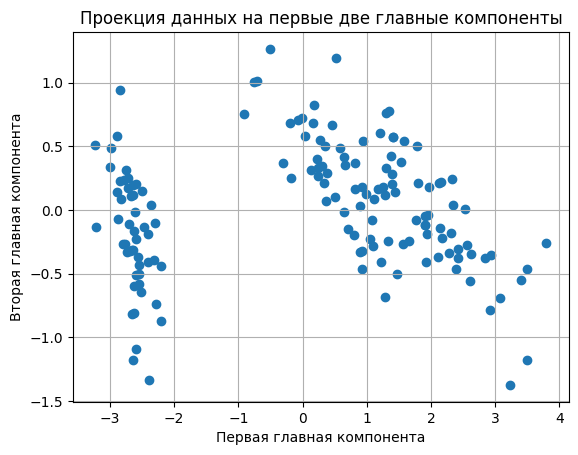

In [22]:
k = 2

X_proj, gamma = pca(X, k)

fig = plot_pca_projection(X_proj)

print(f"Доля объяснённой дисперсии для k = {k}: {gamma:.4f}")

## `reconstruction_error(X_orig, X_recon)`

Эта функция считает среднеквадратическую ошибку восстановления данных.  
Я прохожу по всем элементам исходной и восстановленной матрицы, считаю разницу, возвожу её в квадрат и усредняю по всем элементам. Чем меньше MSE, тем ближе восстановленные данные к исходным.


In [17]:
def reconstruction_error(X_orig: 'Matrix', X_recon: 'Matrix') -> float:
  """
  Вход:
  X_orig: исходные данные (n×m)
  X_recon: восстановленные данные (n×m)
  Выход: среднеквадратическая ошибка MSE
  """

  if X_orig.rows != X_recon.rows:
    raise ValueError("X_orig and X_recon must have the same number of rows")

  if X_orig.cols != X_recon.cols:
    raise ValueError("X_orig and X_recon must have the same number of columns")

  error_sum = 0.0

  for i in range(X_orig.rows):
    for j in range(X_orig.cols):
      diff = X_orig[i][j] - X_recon[i][j]
      error_sum += diff ** 2

  return error_sum / (X_orig.rows * X_orig.cols)

## Проверка `reconstruction_error`

Здесь просто маленький тест на двух матрицах одинакового размера.  
Он нужен, чтобы убедиться, что функция ошибки действительно считает среднее значение квадратов отклонений.


In [18]:
X_orig = Matrix([
  [1, 2],
  [3, 4],
  [5, 6]
])

X_recon = Matrix([
  [1.1, 1.9],
  [3.0, 4.2],
  [4.8, 6.1]
])

print(reconstruction_error(X_orig, X_recon))

0.01833333333333335
